Paired valid grid cells: 256195
Spearman ρ = 0.601, p = 0.00e+00


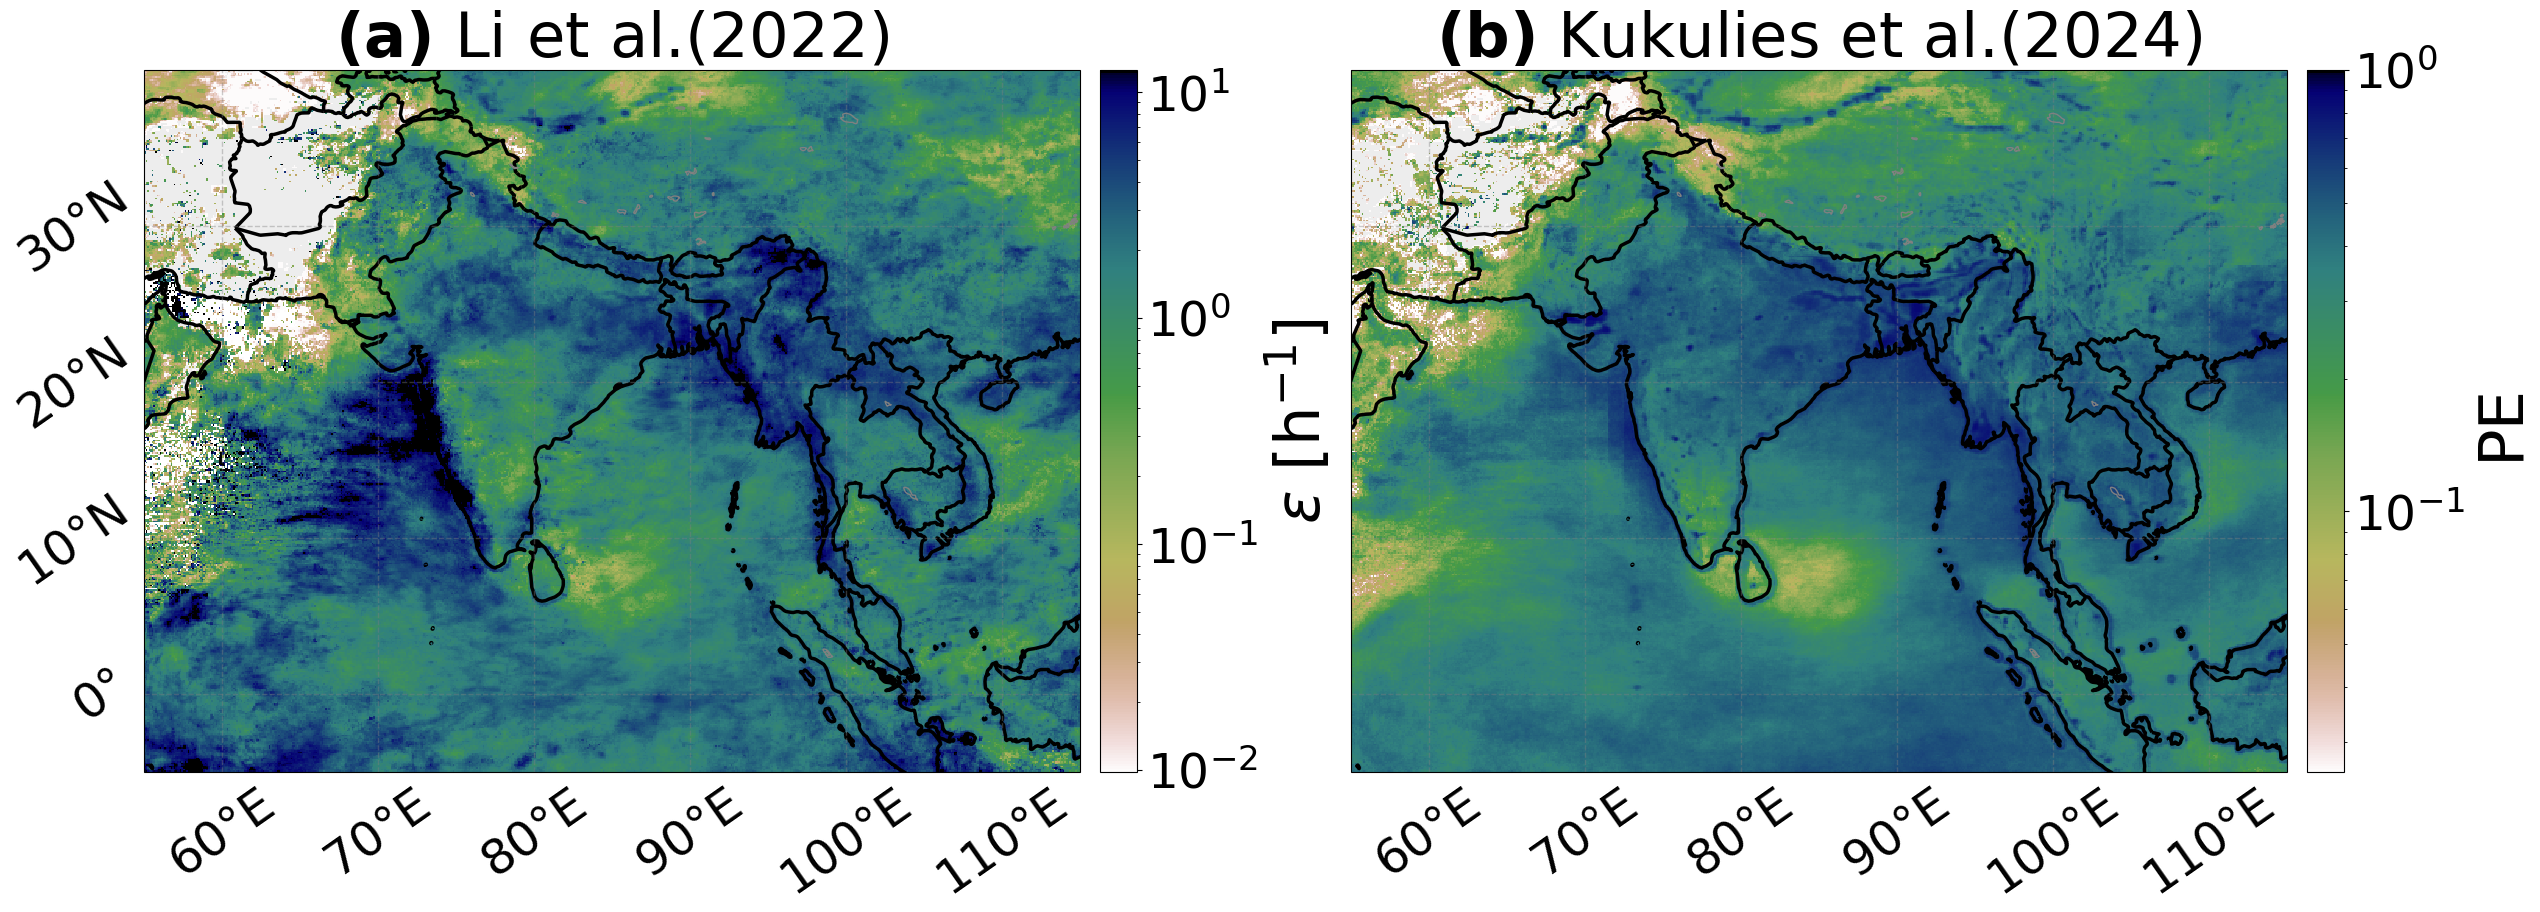

In [1]:
#!/usr/bin/env python3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr
import numpy as np
from scipy.stats import spearmanr

# ------------------------
# INPUT FILES
# ------------------------
# Li et al PE (PRECEFF_TIMEAVG) in s^-1 -> convert to h^-1 for plotting
f_li = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_ciw_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc"

# Julia et al PE (precip_efficiency) ratio 0–1, has time dimension
f_julia = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/Precipitation_Features/Asia_prec_features/PRECEFF_CCIC/non_mcs_precip_efficiency_V22_timeavg.nc"

# AMA extent (lon_min, lon_max, lat_min, lat_max)
extent = (55, 115, -5, 40)

# ------------------------
# HELPERS
# ------------------------
def normalize_lon(da):
    """If lon is 0..360, convert to -180..180 and sort."""
    if "lon" in da.coords and float(da.lon.max()) > 180:
        da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")
    return da

def subset_extent(da, ext):
    lonmin, lonmax, latmin, latmax = ext
    return da.sel(lon=slice(lonmin, lonmax), lat=slice(latmin, latmax))

def add_map(ax, da, title, cmap, norm, show_left=False, show_bottom=True):
    im = ax.pcolormesh(
        da.lon, da.lat, da,
        cmap=cmap, norm=norm, shading="auto",
        transform=ccrs.PlateCarree(),
    )
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=2.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=2.5)
    ax.add_feature(cfeature.LAKES.with_scale("50m"),
                   facecolor="none", edgecolor="0.5", linewidth=1)
    ax.add_feature(cfeature.LAND.with_scale("50m"),
                   facecolor="0.93", edgecolor="none", zorder=-10)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color="gray",
                      alpha=0.4, linestyle="--", draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left
    gl.bottom_labels = show_bottom
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 35, "rotation": 35}
    gl.ylabel_style = {"size": 35, "rotation": 35}

    ax.set_title(title, fontsize=45, pad=6)
    ax.tick_params(axis="x", labelsize=35)
    ax.tick_params(axis="y", labelsize=35)
    im.set_rasterized(True)
    return im

# ------------------------
# LOAD DATA
# ------------------------
# Li et al: PRECEFF_TIMEAVG(lat, lon) in s^-1 -> convert to h^-1
li = xr.open_dataset(f_li)["PRECEFF_TIMEAVG"] * 3600.0
li = normalize_lon(li)
li = subset_extent(li, extent)

# Julia et al: precip_efficiency(time, lat, lon) ratio 0-1
julia = xr.open_dataset(f_julia)["precip_efficiency"]
if "time" in julia.dims:
    julia = julia.isel(time=0)
julia = normalize_lon(julia)
julia = subset_extent(julia, extent)

# Align on identical grid points (inner join)
li_a, julia_a = xr.align(li, julia, join="inner")

# ------------------------
# LOG-SCALE MASKING (must be strictly > 0)
# ------------------------
li_a = li_a.where(li_a > 0)
julia_a = julia_a.where(julia_a > 0)

# ------------------------
# SPEARMAN RHO (paired valid pixels)
# ------------------------
x = li_a.values.ravel()
y = julia_a.values.ravel()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 3:
    rho, pval = spearmanr(x[mask], y[mask])
else:
    rho, pval = np.nan, np.nan

print(f"Paired valid grid cells: {mask.sum()}")
print(f"Spearman ρ = {rho:.3f}, p = {pval:.2e}")

# ------------------------
# LOG COLOR NORMALIZATION (separate norms; same cmap)
# ------------------------
cmap = "gist_earth_r"

# Li (h^-1): robust bounds (avoid zeros due to log)
li_vals = li_a.values
li_valid = np.isfinite(li_vals)
li_vmin = np.nanpercentile(li_vals[li_valid], 1) if np.any(li_valid) else 1e-3
li_vmax = np.nanpercentile(li_vals[li_valid], 99) if np.any(li_valid) else 1.0
li_norm = mcolors.LogNorm(vmin=li_vmin, vmax=li_vmax)

# Julia (0–1): robust lower bound, fixed upper bound at 1
j_vals = julia_a.values
j_valid = np.isfinite(j_vals)
j_vmin = np.nanpercentile(j_vals[j_valid], 1) if np.any(j_valid) else 1e-3
j_norm = mcolors.LogNorm(vmin=j_vmin, vmax=1.0)

# ------------------------
# PLOT (1x2; each panel with its own adjacent colorbar)
# ------------------------
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(24, 9), subplot_kw={"projection": proj})
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.10, top=0.88, wspace=0.15)

t_left  = r"$\bf{(a)}$ Li et al.(2022)"
t_right = r"$\bf{(b)}$ Kukulies et al.(2024)"

im0 = add_map(axes[0], li_a, t_left, cmap, li_norm, show_left=True, show_bottom=True)
im1 = add_map(axes[1], julia_a, t_right, cmap, j_norm, show_left=False, show_bottom=True)

# --- Colorbar next to LEFT panel (force plain Axes; avoids Cartopy projection error)
div0 = make_axes_locatable(axes[0])
cax0 = div0.append_axes("right", size="4%", pad=0.2, axes_class=plt.Axes)
cb0 = fig.colorbar(im0, cax=cax0, orientation="vertical")
cb0.set_label(r"$\epsilon$ [h$^{-1}$]", fontsize=45)
cb0.ax.tick_params(labelsize=35)

# --- Colorbar next to RIGHT panel (force plain Axes; avoids Cartopy projection error)
div1 = make_axes_locatable(axes[1])
cax1 = div1.append_axes("right", size="4%", pad=0.2, axes_class=plt.Axes)
cb1 = fig.colorbar(im1, cax=cax1, orientation="vertical")
cb1.set_label(r"PE", fontsize=45)
cb1.ax.tick_params(labelsize=35)

# Optional save
fig.savefig("/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/PE_Li_vs_Julia_log_spearman.png",
             dpi=200, bbox_inches="tight")
fig.savefig("/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/PE_Li_vs_Julia_log_spearman.pdf",
             dpi=200, bbox_inches="tight")

#plt.show()
